# Dataset EDA
Label frequency, text length, and label cardinality for a prepared XMTC dataset.

In [1]:
import os, sys
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')
sys.path.insert(0, 'src')
import matplotlib.pyplot as plt
import numpy as np
from cascade.data.loaders import load_processed

DATASET = 'eurlex-4k'
train_df, test_df, labels_df, inv_propensity = load_processed(DATASET)
print(f"{DATASET}: {len(train_df)} train, {len(test_df)} test, {len(labels_df)} labels")

eurlex-4k: 15449 train, 3865 test, 3956 labels


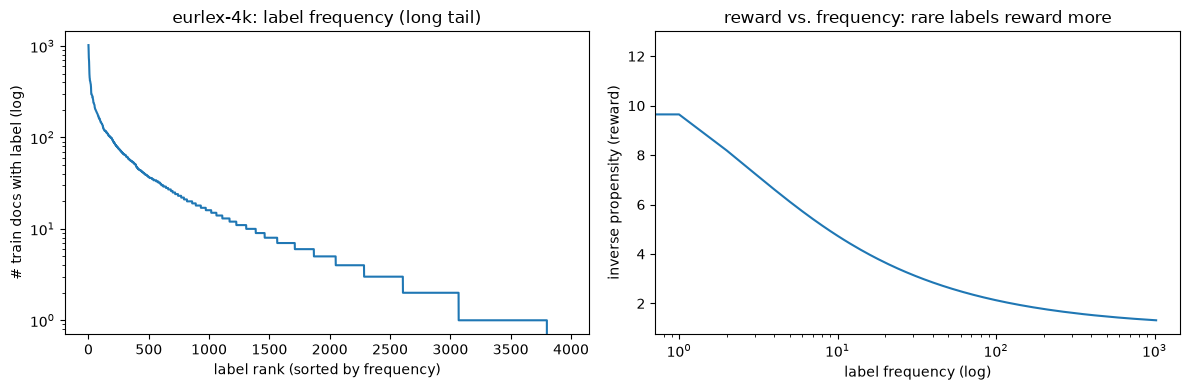

In [2]:
label_freq = np.zeros(len(labels_df), dtype=int)
for ids in train_df['label_ids']:
    for l in ids:
        label_freq[l] += 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.sort(label_freq)[::-1])
axes[0].set_yscale('log')
axes[0].set_xlabel('label rank (sorted by frequency)')
axes[0].set_ylabel('# train docs with label (log)')
axes[0].set_title(f'{DATASET}: label frequency (long tail)')

axes[1].plot(np.sort(label_freq)[::-1], inv_propensity[np.argsort(-label_freq)])
axes[1].set_xscale('log')
axes[1].set_xlabel('label frequency (log)')
axes[1].set_ylabel('inverse propensity (reward)')
axes[1].set_title('reward vs. frequency: rare labels reward more')
plt.tight_layout()
plt.savefig('reports/figures/01_label_frequency_and_reward.png', dpi=150)
plt.show()

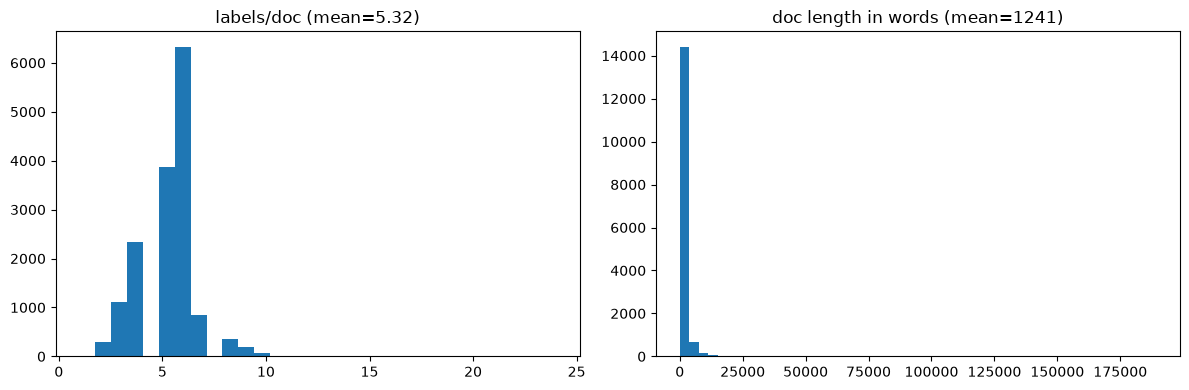

In [3]:
labels_per_doc = train_df['label_ids'].apply(len)
text_len_words = train_df['text'].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(labels_per_doc, bins=30)
axes[0].set_title(f'labels/doc (mean={labels_per_doc.mean():.2f})')
axes[1].hist(text_len_words, bins=50)
axes[1].set_title(f'doc length in words (mean={text_len_words.mean():.0f})')
plt.tight_layout()
plt.savefig('reports/figures/02_doc_label_cardinality.png', dpi=150)
plt.show()